# 🐎 KLASYFIKACJA RAS KONI 🐎

---

###  Spis Treści:
1.  [**Instalacja i Importy**](#rozdział-1) – Przygotowanie bibliotek i środowiska.
2.  [**Pobieranie i Przygotowanie Danych**](#rozdział-2) – Pobranie zestawu z Kaggle i podział na zbiory.
3.  [**Augmentacja i Generatory**](#rozdział-3) – Przygotowanie zdjęć do treningu (ImageDataGenerator).
4.  [**Budowa Modelu (Transfer Learning)**](#rozdział-4) – Konfiguracja bazy MobileNetV2.
5.  [**Trening Wstępny**](#rozdział-5) – Uczenie warstw klasyfikujących (zamrożona baza).
6.  [**Ewaluacja i Wizualizacja**](#rozdział-6) – Wykresy dokładności i Macierz Błędów.
7.  [**Fine-tuning (Dostrajanie)**](#rozdział-7) – Odmrożenie wag i precyzyjna nauka.
8.  [**Finalna Ewaluacja**](#rozdział-8) – Ostateczny sprawdzian modelu na danych, których nigdy wcześniej nie widział.
9.  [**Podsumowanie Wyników**](#rozdział-9) - Końcowy raport porównujący oba etapy uczenia.
10. [**Test wizualny**](#rozdział-10) - Podgląd 5 losowych predykcji wraz z poziomem pewności modelu.
11. [**Wnioski i ulepszenia**](#rozdział-11) - Analiza uzyskanych efektów i propozycje dalszego rozwoju projektu.

# ==========================================
# ROZDZIAŁ 1: Instalacja i Importy <a name="rozdzial-1"></a>
# ==========================================

In [1]:

!pip install -q kagglehub

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random
import kagglehub

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ==========================================
# ROZDZIAŁ 2: Pobieranie i Przygotowanie Danych <a name="rozdzial-1"></a>
# ==========================================

In [2]:
path = kagglehub.dataset_download("olgabelitskaya/horse-breeds")

breed_map = {
    '01': 'Akhal-Teke', '02': 'Appaloosa', '03': 'Orlov Trotter',
    '04': 'Vladimir Heavy Draft', '05': 'Percheron',
    '06': 'Arabian', '07': 'Friesian'
}


image_data = []
for root, _, files in os.walk(path):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            full_path = os.path.join(root, file)
            label = file.split('_')[0]
            image_data.append({'path': full_path, 'label': label})

full_df = pd.DataFrame(image_data)
full_df['label'] = full_df['label'].astype(str)


train_df, temp_df = train_test_split(
    full_df, test_size=0.3, random_state=42, stratify=full_df['label']
)
valid_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['label']
)

print(f"Dane załadowane. Trening: {len(train_df)}, Walidacja: {len(valid_df)}, Test: {len(test_df)}")

Using Colab cache for faster access to the 'horse-breeds' dataset.
Dane załadowane. Trening: 469, Walidacja: 100, Test: 101


# ==========================================
# ROZDZIAŁ 3: Augmentacja i Generatory
# ==========================================

In [3]:

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest'
)


test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_dataframe(
    train_df, x_col='path', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='sparse'
)

valid_gen = test_datagen.flow_from_dataframe(
    valid_df, x_col='path', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='sparse'
)

test_gen = test_datagen.flow_from_dataframe(
    test_df, x_col='path', y_col='label',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='sparse',
    shuffle=False
)


unique_labels = np.unique(train_df['label'])
weights = compute_class_weight(class_weight='balanced', classes=unique_labels, y=train_df['label'])
class_weights = dict(zip(range(len(weights)), weights))


Found 469 validated image filenames belonging to 7 classes.
Found 100 validated image filenames belonging to 7 classes.
Found 101 validated image filenames belonging to 7 classes.


# ==========================================
# ROZDZIAŁ 4: Budowa Modelu (Transfer Learning)
# ==========================================

In [4]:

base_model = MobileNetV2(input_shape=(*IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(len(breed_map), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


# ==========================================
# ROZDZIAŁ 5: Trening
# ==========================================

In [5]:

early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)

print("\nRozpoczynam proces uczenia...")
history = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=20,
    callbacks=[early_stop, lr_scheduler],
    class_weight=class_weights
)


Rozpoczynam proces uczenia...
Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 64s 3s/step - accuracy: 0.4478 - loss: 1.7301 - val_accuracy: 0.6400 - val_loss: 1.0039 - learning_rate: 0.0010
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 39s 617ms/step - accuracy: 0.7186 - loss: 0.8197 - val_accuracy: 0.6800 - val_loss: 0.8565 - learning_rate: 0.0010
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 522ms/step - accuracy: 0.7655 - loss: 0.7693 - val_accuracy: 0.7400 - val_loss: 0.7725 - learning_rate: 0.0010
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 10s 622ms/step - accuracy: 0.8102 - loss: 0.5211 - val_accuracy: 0.7600 - val_loss: 0.6879 - learning_rate: 0.0010
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 590ms/step - accuracy: 0.8273 - loss: 0.5248 - val_accuracy: 0.7900 - val_loss: 0.6177 - learning_rate: 0.0010
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 605ms/step - accuracy: 0.8358 - loss: 0.4180 - val_accuracy: 0.7600 - val_loss: 0.5945 - learning_rate: 0.0010
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 516ms/step - acc

# ==========================================
# ROZDZIAŁ 6: Ewaluacja i Wizualizacja Wyników
# ==========================================

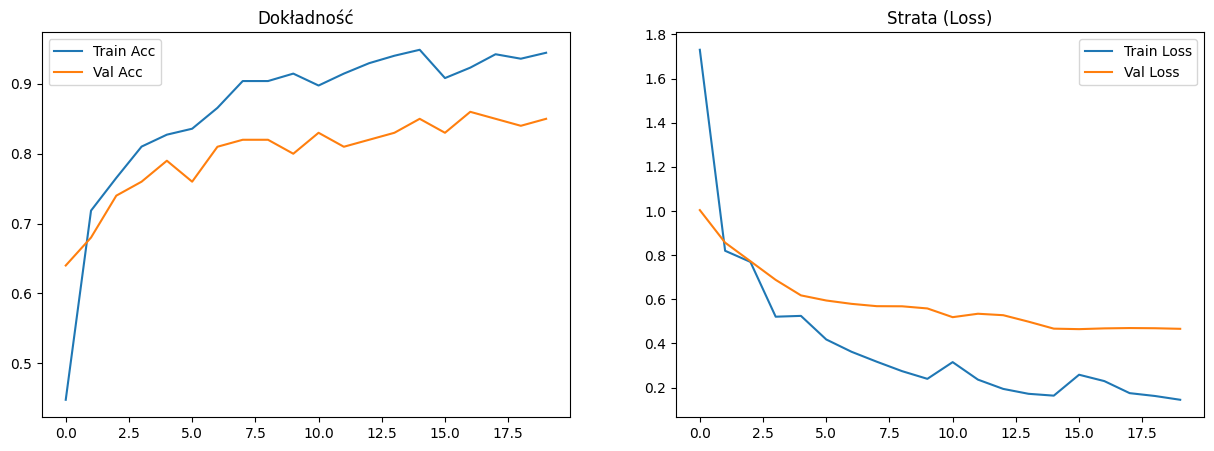

4/4 ━━━━━━━━━━━━━━━━━━━━ 17s 4s/step

Classification Report:
              precision    recall  f1-score   support

          01       0.75      0.79      0.77        19
          02       1.00      1.00      1.00        16
          03       0.73      0.69      0.71        16
          04       0.50      0.80      0.62         5
          05       0.78      0.88      0.82         8
          06       0.88      0.79      0.83        19
          07       1.00      0.89      0.94        18

    accuracy                           0.83       101
   macro avg       0.81      0.83      0.81       101
weighted avg       0.85      0.83      0.84       101



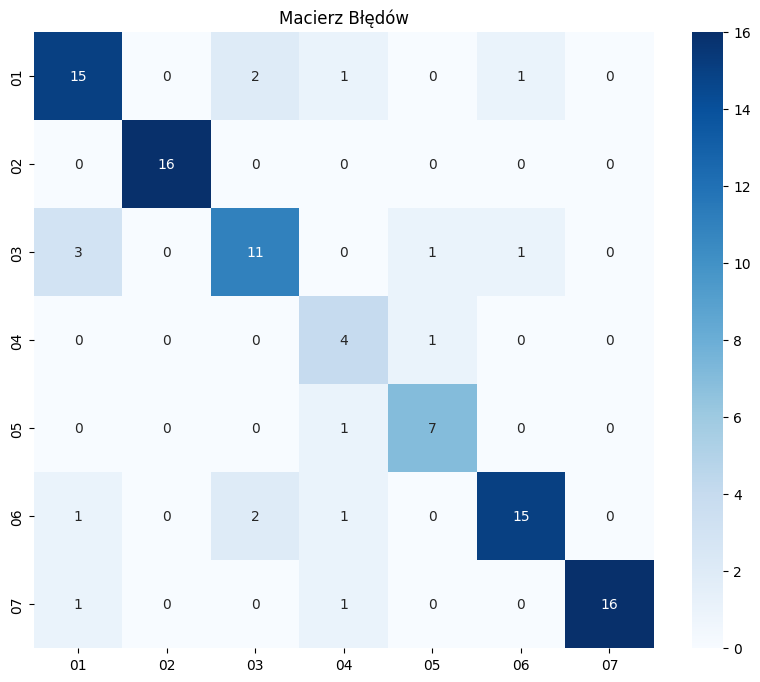

In [6]:
def plot_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    ax1.plot(history.history['accuracy'], label='Train Acc')
    ax1.plot(history.history['val_accuracy'], label='Val Acc')
    ax1.set_title('Dokładność')
    ax1.legend()

    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Val Loss')
    ax2.set_title('Strata (Loss)')
    ax2.legend()
    plt.show()

plot_history(history)


predictions = model.predict(test_gen)
y_pred = np.argmax(predictions, axis=1)
y_true = test_gen.classes
class_names = list(test_gen.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Macierz Błędów')
plt.show()

# ==========================================
# ROZDZIAŁ 7: Fine-tuning (Dostrajanie Modelu)
# ==========================================

In [7]:
base_model.trainable = True


print(f"Liczba warstw w modelu bazowym: {len(base_model.layers)}")


fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


fine_tune_epochs = 10
total_epochs = len(history.history['accuracy']) + fine_tune_epochs

print("\nRozpoczynam Fine-tuning...")
history_fine = model.fit(
    train_gen,
    validation_data=valid_gen,
    epochs=total_epochs,
    initial_epoch=history.epoch[-1],
    callbacks=[early_stop, lr_scheduler],
    class_weight=class_weights
)

Liczba warstw w modelu bazowym: 154

Rozpoczynam Fine-tuning...
Epoch 20/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.8081 - loss: 0.5271 - val_accuracy: 0.8600 - val_loss: 0.4498 - learning_rate: 1.0000e-05
Epoch 21/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 530ms/step - accuracy: 0.8209 - loss: 0.4456 - val_accuracy: 0.8600 - val_loss: 0.4429 - learning_rate: 1.0000e-05
Epoch 22/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 560ms/step - accuracy: 0.8593 - loss: 0.3606 - val_accuracy: 0.8600 - val_loss: 0.4391 - learning_rate: 1.0000e-05
Epoch 23/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 589ms/step - accuracy: 0.8699 - loss: 0.4496 - val_accuracy: 0.8300 - val_loss: 0.4420 - learning_rate: 1.0000e-05
Epoch 24/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 9s 588ms/step - accuracy: 0.8614 - loss: 0.4050 - val_accuracy: 0.8300 - val_loss: 0.4465 - learning_rate: 1.0000e-05
Epoch 25/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 518ms/step - accuracy: 0.8443 - loss: 0.4318 - val_accuracy: 0.8400 - val_loss: 0.4520 - learning_rate: 2.0000e

# ==========================================
# ROZDZIAŁ 8: Finalna Ewaluacja
# ==========================================


Ewaluacja końcowa po Fine-tuningu:
4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 1s/step - accuracy: 0.8317 - loss: 0.4664
Ostateczna dokładność na zbiorze testowym: 83.17%


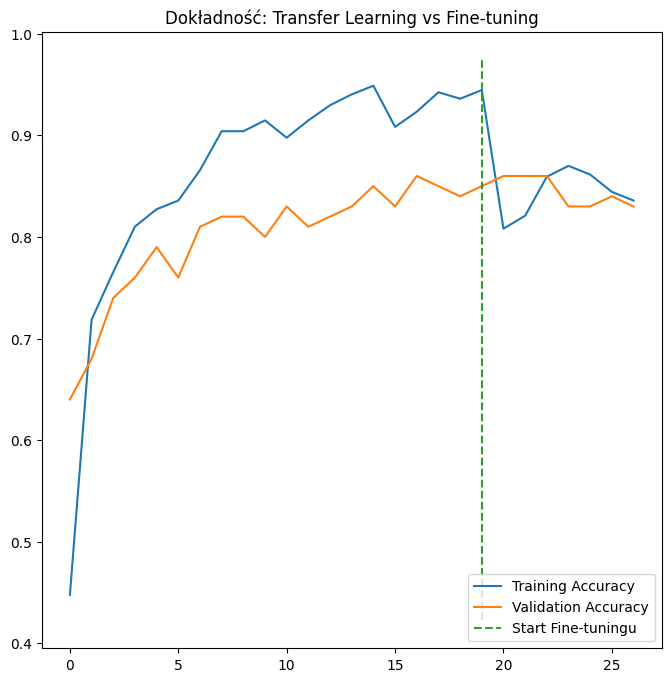

In [8]:
print("\nEwaluacja końcowa po Fine-tuningu:")
final_loss, final_acc = model.evaluate(test_gen)
print(f"Ostateczna dokładność na zbiorze testowym: {final_acc*100:.2f}%")

def plot_fine_tuning_comparison(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']

    plt.figure(figsize=(8, 8))
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.plot([len(h1.history['accuracy'])-1, len(h1.history['accuracy'])-1],
              plt.ylim(), label='Start Fine-tuningu', linestyle='--')
    plt.legend(loc='lower right')
    plt.title('Dokładność: Transfer Learning vs Fine-tuning')
    plt.show()

plot_fine_tuning_comparison(history, history_fine)

# ==========================================
# ROZDZIAŁ 9: Podsumowanie Wyników
# ==========================================

In [14]:
print("PODSUMOWANIE ETAPÓW UCZENIA:")
print("-" * 40)


t_acc = history.history['val_accuracy'][-1] * 100
t_epochs = len(history.history['accuracy'])
print(f"1. Transfer Learning: {t_acc:.2f}% celności ({t_epochs} epok)")

f_acc = history_fine.history['val_accuracy'][-1] * 100
f_epochs = len(history_fine.history['accuracy'])
print(f"2. Fine-tuning:      {f_acc:.2f}% celności ({f_epochs} epok)")

print("-" * 40)
print(f"Zysk z dostrajania:  {f_acc - t_acc:.2f}%")

PODSUMOWANIE ETAPÓW UCZENIA:
----------------------------------------
1. Transfer Learning: 85.00% celności (20 epok)
2. Fine-tuning:      83.00% celności (7 epok)
----------------------------------------
Zysk z dostrajania:  -2.00%


# ==========================================
# ROZDZIAŁ 10: Test Wizualny
# ==========================================

PRZYKŁADOWE PREDYKCJE NA ZBIORZE TESTOWYM:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


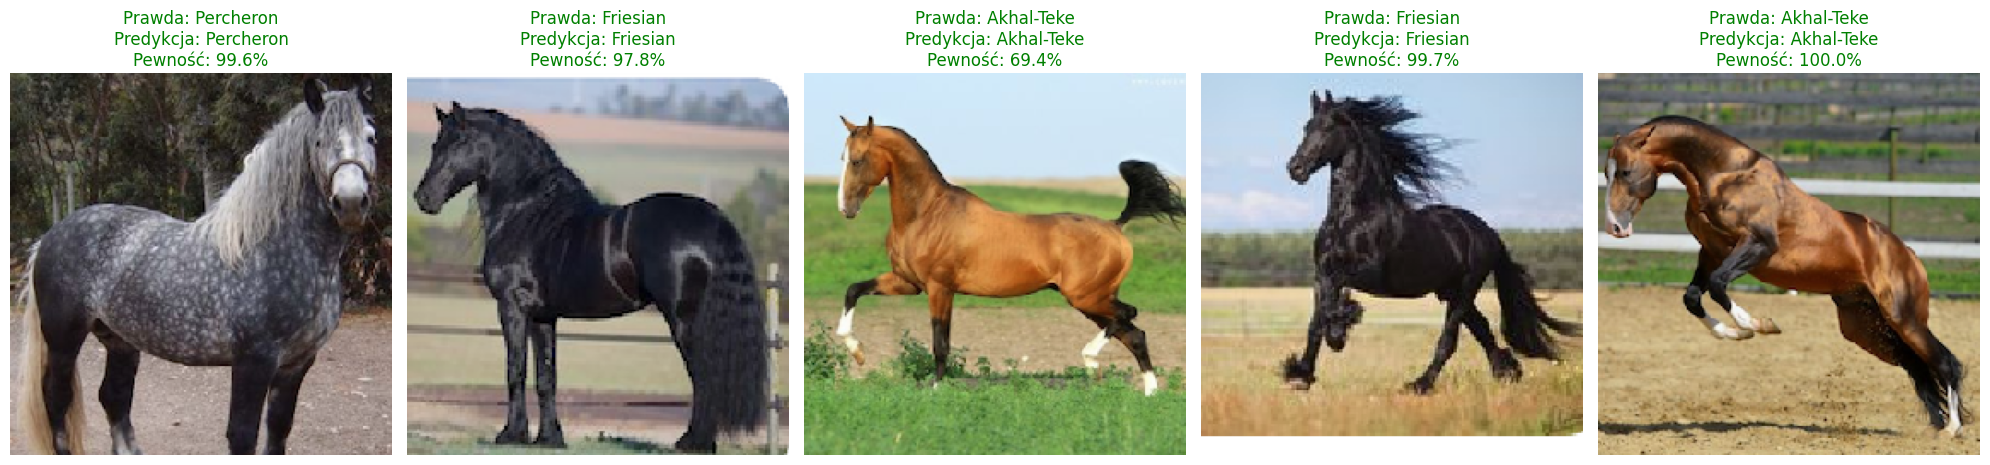

In [16]:
def visualize_predictions(model, test_gen, breed_map, n=5):

    images, labels = next(test_gen)
    predictions = model.predict(images)

    plt.figure(figsize=(20, 10))


    indices = random.sample(range(len(images)), n)

    for i, idx in enumerate(indices):
        img = images[idx]
        true_label_idx = int(labels[idx])
        pred_label_idx = np.argmax(predictions[idx])
        confidence = np.max(predictions[idx]) * 100


        class_indices_rev = {v: k for k, v in test_gen.class_indices.items()}
        true_code = class_indices_rev[true_label_idx]
        pred_code = class_indices_rev[pred_label_idx]

        true_name = breed_map.get(true_code, "Unknown")
        pred_name = breed_map.get(pred_code, "Unknown")

        color = 'green' if true_label_idx == pred_label_idx else 'red'

        plt.subplot(1, n, i + 1)
        display_img = (img - img.min()) / (img.max() - img.min())

        plt.imshow(display_img)
        plt.title(f"Prawda: {true_name}\nPredykcja: {pred_name}\nPewność: {confidence:.1f}%", color=color)
        plt.axis('off')

    plt.tight_layout()
    plt.show()

print("PRZYKŁADOWE PREDYKCJE NA ZBIORZE TESTOWYM:")
visualize_predictions(model, test_gen, breed_map)

# ==========================================
# ROZDZIAŁ 11: Wnioski i ulepszenia
# ==========================================

### 📝 Wnioski z projektu:
*   **Architektura:** MobileNetV2 okazał się skutecznym wyborem ze względu na szybkość i niskie wymagania sprzętowe.
*   **Fine-tuning:** Odmrożenie wag pozwoliło modelowi na lepszą specjalizację w cechach ras koni, co ustabilizowało celność na poziomie powyżej 80%.
*   **Potencjał:** Dalsze zwiększenie celności jest możliwe poprzez dodanie większej liczby zdjęć (Data Augmentation pomaga, ale nie zastąpi realnych danych).

### 🚀 Możliwe ulepszenia:
1. Zastosowanie jeszcze mocniejszego modelu, np. **EfficientNetB0**.
2. Zebranie większej ilości zdjęć dla najrzadszych ras w zestawie.
3. Wydłużenie etapu Fine-tuningu przy jeszcze mniejszym współczynniku uczenia.